# 03: Boundary Conditions Showcase

Demonstrates all boundary condition types and their effects on solution behavior.

In [18]:
# Setup
import sys, os
repo_root = os.path.dirname(os.getcwd())
src_path = os.path.join(repo_root, "src")
if os.path.isdir(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import matplotlib.pyplot as plt
from stochlib import configure_logging, get_logger
import logging

configure_logging(level=logging.INFO, verbose=True)
logger = get_logger("notebook")
logger.info("Starting boundary conditions notebook")

2026-01-20 00:05:45,106 [INFO    ] stochlib.notebook: Starting boundary conditions notebook


In [19]:
# Import components (minimal, library-first)
from stochlib.setup import Grid, InitialCondition, VelocitiesConfig, DiffusionConfig
from stochlib.boundary_conditions import BoundaryConditions
from stochlib.fokker_planck import SimulationEngine

logger.info("Imported Fokker-Planck components")

2026-01-20 00:05:45,273 [INFO    ] stochlib.notebook: Imported Fokker-Planck components


## Setup Common Parameters

In [20]:
# Common setup (1D domain)
grid = Grid(x_start=0.0, x_end=1.0, num_points_x=201)

# Gaussian initial condition centered in domain
ic = InitialCondition(grid, func_type="gaussian", x0=0.5, sigma_x=0.1)

# Constant diffusion, zero drift
velocities = VelocitiesConfig(grid, mu_x=0.0)
diffusions = DiffusionConfig(grid, axes=['x'], constants={'x': 0.1})

# Time array (CFL-safe)
t_array = np.linspace(0.0, 0.05, 501)  # dt=1e-4 < dt_max

logger.info(f"Grid: {grid.shape} spanning [{grid.x_start}, {grid.x_end}]")

2026-01-20 00:05:45,780 [INFO    ] stochlib.notebook: Grid: (201,) spanning [0.0, 1.0]


## Part 1: Periodic Boundary Conditions

In [21]:
# Helper to run a case with a chosen boundary type

def run_case(bc_x: str):
    bc = BoundaryConditions(grid, bc_x=bc_x)
    engine = SimulationEngine(grid, velocities, diffusions, bc)
    result = engine.run(
        f0=ic.f0,
        t_array=t_array,
        save_interval=10,
        confirm_run=False,
    )
    return result

logger.info("Defined run_case helper")

2026-01-20 00:05:46,556 [INFO    ] stochlib.notebook: Defined run_case helper


In [22]:
# Run all boundary-condition variants (supported: open, noflux, periodic)
results = {
    'periodic': run_case('periodic'),
    'noflux': run_case('noflux'),
    'open': run_case('open'),
}
logger.info("Solved all BC variants")

2026-01-20 00:05:46,907 [INFO    ] stochlib.fokker_planck.selector: Engine Decision: {'x': 'central_cn'}

               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x
  Total grid points    : 201
  Grid deltas (Δ)      : {'x': np.float64(0.005)}
  Volume element (dV)  : 5.000e-03

BOUNDARY CONDITIONS:
  x      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 0.000e+00
  Max diffusion (D)    : 1.000e-01

TIME STEPPING:
  dt (requested)       : 1.000e-04
  dt_max (CFL stable)  : 1.250e-04
  Total steps          : 500
  Time window          : [t=0.000e+00, t=5.000e-02]

NUMERICAL SCHEMES:
  x      : central_cn

DIAGNOSTICS:
  Report interval      : every 10 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0000 GB
  Num fields           : 3 (f + velocities + diffusion)
  Est. total memory    : 0.0000 GB
  Est. runtime         : 0.0080 s (rough; peak may vary)

======== RUNTIME REPORT ========
step       : 10
ti

## Part 2: No-Flux (Neumann) Boundary Conditions

In [23]:
# Extract snapshots and times for convenience
snapshots = {name: np.array(res['snapshots']) for name, res in results.items()}
snapshot_times = {name: np.array(res['times']) for name, res in results.items()}
x = grid.x_grid

logger.info("Prepared snapshot arrays")

2026-01-20 00:05:55,040 [INFO    ] stochlib.notebook: Prepared snapshot arrays


## Part 3: Absorbing Boundary Conditions

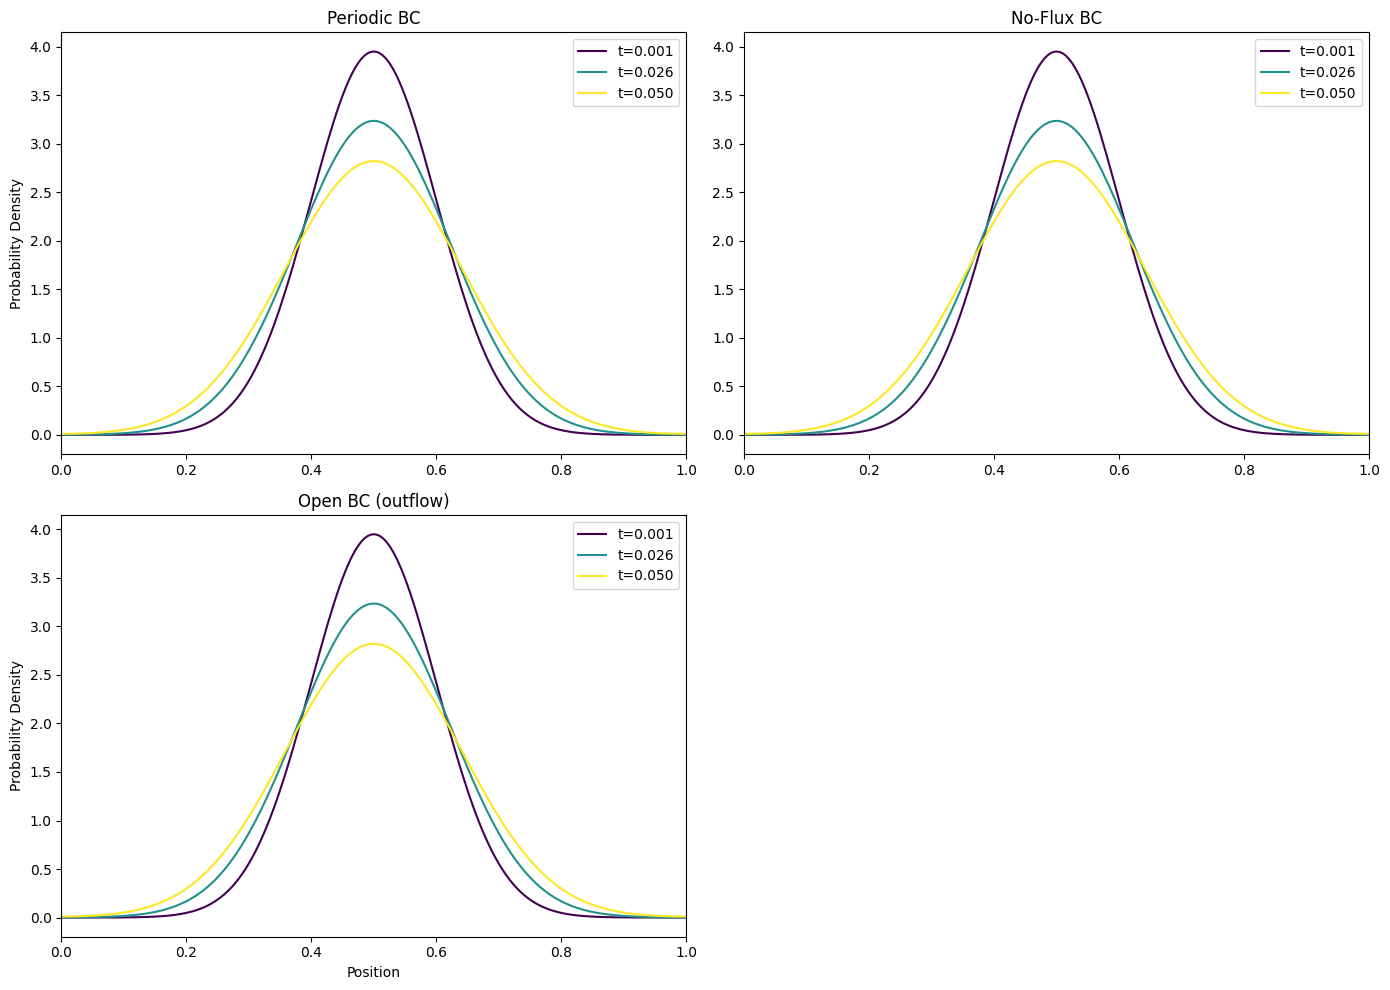

2026-01-20 00:05:57,136 [INFO    ] stochlib.notebook: Plotted boundary condition comparison


In [24]:
# Plot evolution for each BC
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

steps_idx = [0, len(snapshot_times['periodic']) // 2, -1]
colors = plt.colormaps['viridis'](np.linspace(0, 1, len(steps_idx)))

cases = [
    ('periodic', axes[0, 0], 'Periodic BC'),
    ('noflux', axes[0, 1], 'No-Flux BC'),
    ('open', axes[1, 0], 'Open BC (outflow)'),
]

for name, ax, title in cases:
    s = snapshots[name]
    t = snapshot_times[name]
    for idx, step in enumerate(steps_idx):
        ax.plot(x, s[step], color=colors[idx], label=f"t={t[step]:.3f}")
    ax.set_title(title)
    ax.set_xlim(grid.x_start, grid.x_end)
    ax.legend()
axes[0, 0].set_ylabel('Probability Density')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].set_xlabel('Position')
axes[1, 1].axis('off')  # unused panel

plt.tight_layout()
plt.show()

logger.info("Plotted boundary condition comparison")

## Results: Boundary Condition Comparison

### What to look for
- Periodic and No-Flux should preserve the total mass curve.
- Open BC should show decreasing mass over time as probability exits the domain.
- Shapes of the snapshots illustrate how boundaries affect density spreading and loss.

## Mass Conservation Analysis

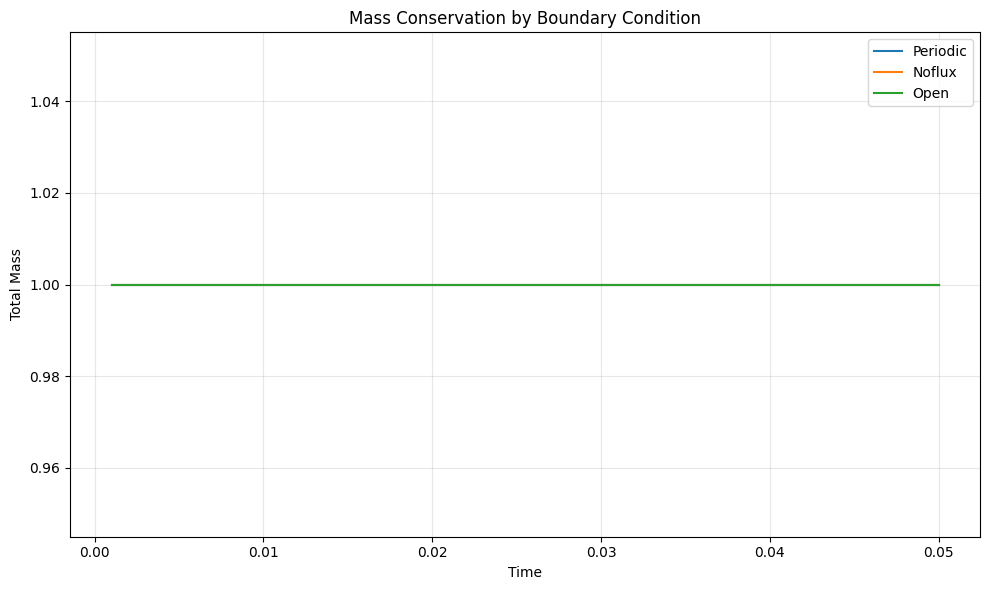

2026-01-20 00:06:02,295 [INFO    ] stochlib.notebook: Mass conservation analysis complete


In [25]:
# Compute total mass (integral of probability density)
dx = grid.dx

def compute_mass(solutions, dx):
    return np.sum(solutions, axis=1) * dx

mass = {name: compute_mass(snapshots[name], dx) for name in snapshots}

fig, ax = plt.subplots(figsize=(10, 6))
for name, series in mass.items():
    ax.plot(snapshot_times[name], series, label=name.capitalize())
ax.set_xlabel('Time')
ax.set_ylabel('Total Mass')
ax.set_title('Mass Conservation by Boundary Condition')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info("Mass conservation analysis complete")

In [26]:
# Print final mass
print("\nFinal Mass (last saved snapshot):")
for name, series in mass.items():
    print(f"  {name.capitalize():9s}: {series[-1]:.6f}")


Final Mass (last saved snapshot):
  Periodic : 1.000000
  Noflux   : 1.000000
  Open     : 1.000000


## Summary

This notebook compared three boundary condition types with the minimal Fokker–Planck API:

1. Periodic — wraps around the domain
2. No-Flux — conserves mass inside the domain
3. Open — outflow at the boundaries, mass can leave

Key observation: periodic and no-flux conserve mass; open loses mass as expected for outflow.